Importing Kaggle Dataset

In [ ]:
!pip install -q torch torchvision scikit-learn kaggle

In [5]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d prasunroy/natural-images
!mkdir -p data
!unzip -q natural-images.zip -d data/natural_images

Dataset URL: https://www.kaggle.com/datasets/prasunroy/natural-images
License(s): CC-BY-NC-SA-4.0
 97% 332M/342M [00:00<00:00, 667MB/s]
100% 342M/342M [00:00<00:00, 698MB/s]


In [11]:
!mv data/natural_images/natural_images/* data/natural_images/
!rmdir data/natural_images/natural_images


!ls data/natural_images
!rm -rf data/natural_images/data


mv: cannot stat 'data/natural_images/natural_images/*': No such file or directory
rmdir: failed to remove 'data/natural_images/natural_images': No such file or directory
airplane  car  cat  dog  flower  fruit	motorbike  person


In [12]:
!ls -la data/natural_images


total 280
drwxr-xr-x 10 root root  4096 Dec 16 19:13 .
drwxr-xr-x  3 root root  4096 Dec 16 19:10 ..
drwxr-xr-x  2 root root 36864 Dec 16 19:10 airplane
drwxr-xr-x  2 root root 36864 Dec 16 19:10 car
drwxr-xr-x  2 root root 36864 Dec 16 19:10 cat
drwxr-xr-x  2 root root 20480 Dec 16 19:10 dog
drwxr-xr-x  2 root root 36864 Dec 16 19:10 flower
drwxr-xr-x  2 root root 36864 Dec 16 19:10 fruit
drwxr-xr-x  2 root root 36864 Dec 16 19:10 motorbike
drwxr-xr-x  2 root root 36864 Dec 16 19:11 person


In [13]:
!find data/natural_images -maxdepth 1 -type d -print


data/natural_images
data/natural_images/dog
data/natural_images/fruit
data/natural_images/airplane
data/natural_images/car
data/natural_images/flower
data/natural_images/motorbike
data/natural_images/person
data/natural_images/cat


Setup

In [20]:
import tensorflow as tf
from tensorflow import keras
import sklearn
import numpy as np
np.random.seed(42)
import matplotlib as mpl
import matplotlib.pyplot as plt

Load Dataset

In [21]:
DATA_DIR = "data/natural_images"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.15,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.15,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)


Found 6899 files belonging to 8 classes.
Using 5865 files for training.
Found 6899 files belonging to 8 classes.
Using 1034 files for validation.
['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']


In [22]:
from tensorflow.keras import layers, models
cnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(64, 7, padding="same", activation="relu"),
    layers.MaxPool2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),

    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax"),
])

cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = cnn.fit(train_ds, validation_data=val_ds, epochs=15)

Epoch 1/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 65s 331ms/step - accuracy: 0.3912 - loss: 1.9987 - val_accuracy: 0.7640 - val_loss: 0.6483
Epoch 2/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 40s 219ms/step - accuracy: 0.7318 - loss: 0.7241 - val_accuracy: 0.8578 - val_loss: 0.3916
Epoch 3/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 40s 219ms/step - accuracy: 0.8335 - loss: 0.4525 - val_accuracy: 0.8491 - val_loss: 0.3594
Epoch 4/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 40s 219ms/step - accuracy: 0.8505 - loss: 0.4219 - val_accuracy: 0.8656 - val_loss: 0.3274
Epoch 5/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 40s 219ms/step - accuracy: 0.8854 - loss: 0.3100 - val_accuracy: 0.8917 - val_loss: 0.2973
Epoch 6/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 40s 219ms/step - accuracy: 0.9228 - loss: 0.2192 - val_accuracy: 0.8907 - val_loss: 0.2948
Epoch 7/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 40s 219ms/step - accuracy: 0.9249 - loss: 0.1975 - val_accuracy: 0.8985 - val_loss: 0.2826
Epoch 8/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 40s 218ms/step - accuracy: 0.9321 - loss: 0

In [24]:
val_loss, val_acc = cnn.evaluate(val_ds, verbose=1)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.8982 - loss: 0.4396
Validation loss: 0.3901
Validation accuracy: 0.9043


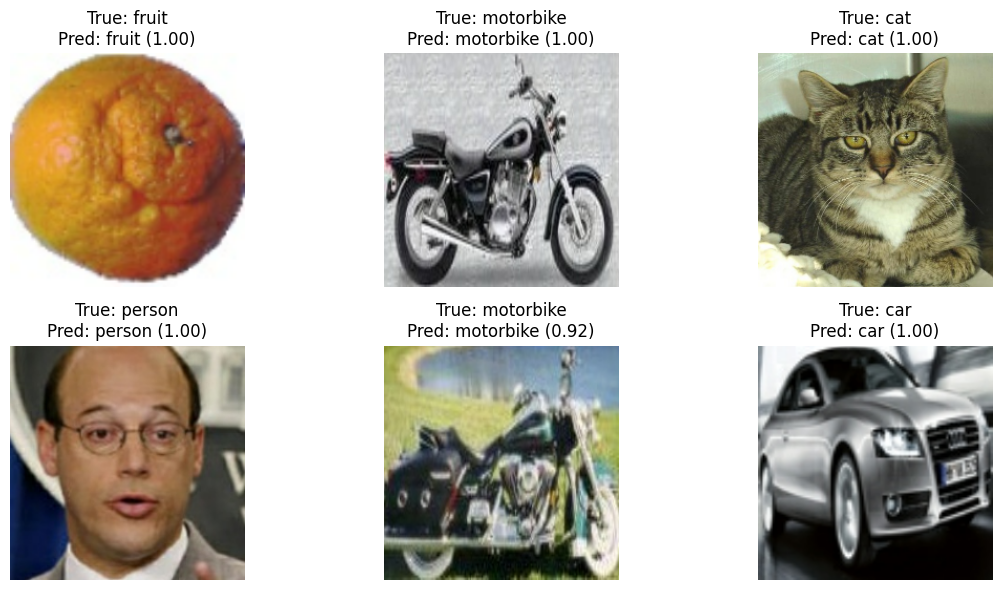

In [32]:
import numpy as np
import matplotlib.pyplot as plt

images, labels = next(iter(val_ds))
probs = cnn.predict(images, verbose=0)
preds = np.argmax(probs, axis=1)

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    true_name = class_names[int(labels[i])]
    pred_name = class_names[int(preds[i])]
    conf = np.max(probs[i])
    plt.title(f"True: {true_name}\nPred: {pred_name} ({conf:.2f})")
    plt.axis("off")
plt.tight_layout()
plt.show()
